# 1-D tube model: Xu & Froment (1989) Part II case

Single-tube pseudo-homogeneous plug-flow simulation (`rdt.reactor1d`) of the Xu & Froment Part II Table 2
reformer (ID 0.1016 m, OD 0.1322 m, 11.12 m heated, 29 bar, 793 K inlet, S/C 3.358) with a **prescribed
linear outer-wall temperature** from 1000 K at the inlet to 1150 K at the outlet and effectiveness factors
0.1 (Latham 2011 assumption). Panels follow the layout of Xu & Froment Part II Fig. 3 (p. 101) so the two can be
compared once that figure is digitised. Bed density and equivalent ring diameter are project assumptions
(see `reactor1d.bed_from_xu_froment`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from rdt import reactor1d as r1

tube = r1.tube_from_xu_froment()
bed = r1.bed_from_xu_froment()
feed = r1.feed_from_xu_froment()
wall = r1.WallBC.linear(1000.0, 1150.0, tube.L_heated)
print(tube); print(bed); print(feed)

res = r1.simulate(tube, bed, feed, wall)
print(res.message, "| RHS evaluations:", res.n_rhs_evals, "| wall time: %.2f s" % res.wall_time_s)
for k, v in res.outlet().items():
    print(f"{k:>18s}: {v:.4f}")
print("pressure drop [bar]: %.3f" % (res.P[0] - res.P[-1]))
print("peak outer heat flux [kW/m2]: %.1f at z = %.2f m" % (res.q_flux_outer.max() / 1e3, res.z[res.q_flux_outer.argmax()]))


TubeGeometry(d_i=0.1016, d_o=0.1322, L_heated=11.12, lambda_tube=29.583333333333332)
CatalystBed(rho_bed=942.0799999999999, voidage=0.6, d_p=0.009238754325259516, eta=(0.1, 0.1, 0.1), activity=1.0)
Feed(T_in=793.15, P_in=29.0, F={'CH4': 5.168, 'H2O': 17.354144, 'CO2': 0.289408, 'H2': 0.6304960000000001, 'N2': 0.8475520000000001, 'CO': 0.0})


The solver successfully reached the end of the integration interval. | RHS evaluations: 1640 | wall time: 0.26 s
               z_m: 11.1200
               T_K: 1084.8925
             P_bar: 27.3474
    conversion_CH4: 0.7171
         yield_CO2: 0.3174
          X_H2_dry: 0.6799
    T_wall_outer_K: 1150.0000
    T_wall_inner_K: 1123.2273
   dT_approach_I_K: 3.2763
pressure drop [bar]: 1.653
peak outer heat flux [kW/m2]: 116.8 at z = 0.17 m


saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig02_reactor_profiles.png


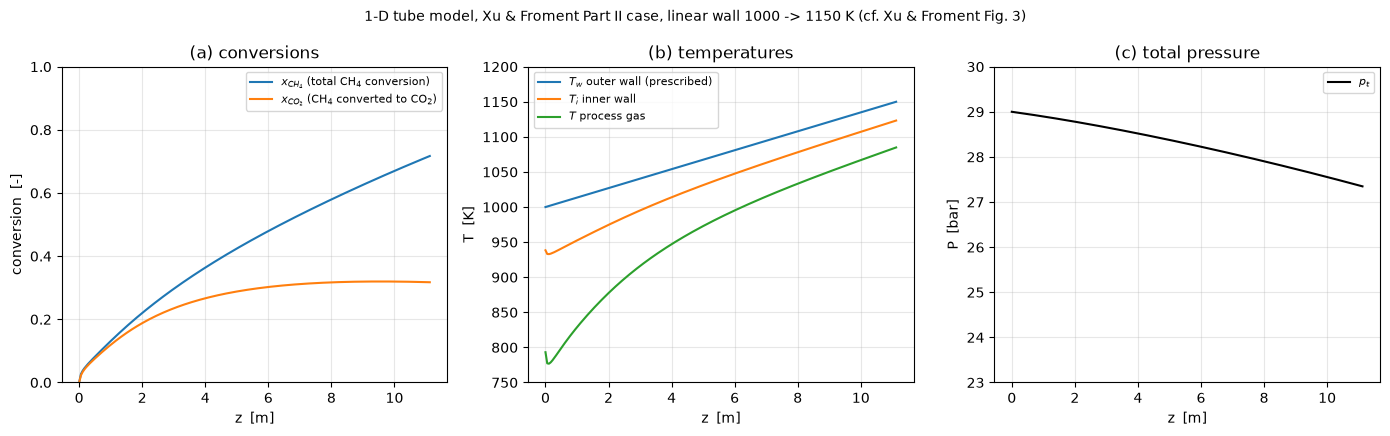

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
z = res.z

ax = axes[0]
ax.plot(z, res.conversion_CH4, label=r"$x_{CH_4}$ (total CH$_4$ conversion)")
ax.plot(z, res.yield_CO2, label=r"$x_{CO_2}$ (CH$_4$ converted to CO$_2$)")
ax.set_xlabel("z  [m]"); ax.set_ylabel("conversion  [-]"); ax.set_ylim(0, 1)
ax.set_title("(a) conversions"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(z, res.T_wall_outer, label=r"$T_w$ outer wall (prescribed)")
ax.plot(z, res.T_wall_inner, label=r"$T_i$ inner wall")
ax.plot(z, res.T, label=r"$T$ process gas")
ax.set_xlabel("z  [m]"); ax.set_ylabel("T  [K]"); ax.set_ylim(750, 1200)
ax.set_title("(b) temperatures"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[2]
ax.plot(z, res.P, color="k", label=r"$p_t$")
ax.set_xlabel("z  [m]"); ax.set_ylabel("P  [bar]"); ax.set_ylim(23, 30)
ax.set_title("(c) total pressure"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

fig.suptitle("1-D tube model, Xu & Froment Part II case, linear wall 1000 -> 1150 K (cf. Xu & Froment Fig. 3)", fontsize=10)
fig.tight_layout()
out = Path("..") / "paper" / "figures" / "fig02_reactor_profiles.png"
fig.savefig(out, dpi=150); print("saved", out.resolve())
plt.show()


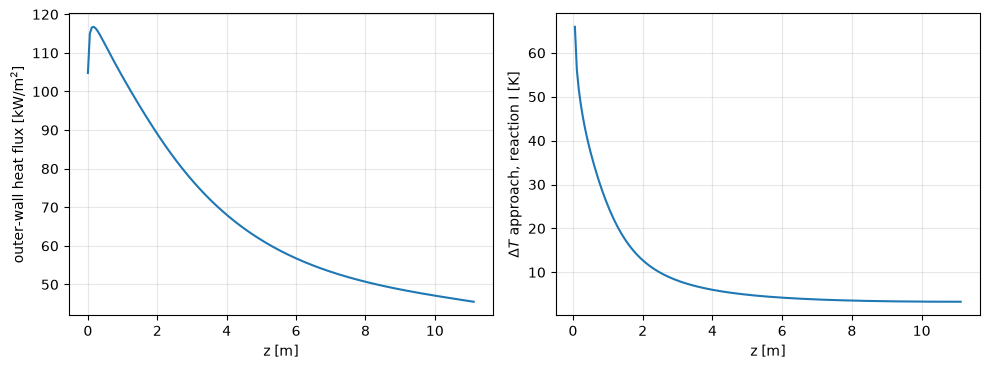

outlet wet mole fractions: {'CH4': 0.0461, 'H2O': 0.3788, 'H2': 0.4224, 'CO': 0.0652, 'CO2': 0.0609, 'N2': 0.0267}
outlet dry mole fractions: {'CH4': 0.0742, 'H2': 0.6799, 'CO': 0.1049, 'CO2': 0.098, 'N2': 0.043}


In [3]:
# Diagnostics: heat flux and approach to equilibrium (cf. Xu & Froment Fig. 5)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(z, res.q_flux_outer / 1e3); ax[0].set_xlabel("z [m]"); ax[0].set_ylabel("outer-wall heat flux [kW/m$^2$]"); ax[0].grid(alpha=0.3)
ax[1].plot(z, res.dT_approach_I); ax[1].set_xlabel("z [m]"); ax[1].set_ylabel(r"$\Delta T$ approach, reaction I [K]"); ax[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()
dry = res.dry_mole_fractions
print("outlet wet mole fractions:", {s: round(float(res.X[s][-1]), 4) for s in r1.SPECIES})
print("outlet dry mole fractions:", {s: round(float(v[-1]), 4) for s, v in dry.items()})
